In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import scipy.io
import matplotlib.pyplot as plt
import os

import warnings
warnings.filterwarnings("ignore")

#os.environ["CUDA_VISIBLE_DEVICES"] = "4"

import sys
sys.path.append(r'/import/home2/share/yqzeng/MacSGP/codes')
import MacSGP

In [2]:
RAW_PATH = "/home/yzengbj/my_project/data/kidney_cancer" # Raw data
DATA_PATH = "/home/yzengbj/factor/data/kidney_cancer" # Processed data
SAVE_PATH = "/home/yzengbj/factor/results/kidney_cancer" # Deconvolution results
os.makedirs(os.path.join(DATA_PATH), exist_ok = True)
os.makedirs(os.path.join(SAVE_PATH), exist_ok = True)

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import pearsonr
from libpysal.weights import KNN
import matplotlib as mpl

# ============================================================
# 全局绘图风格设置 (Nature Communications 标准)
# ============================================================
mpl.rcParams.update({
    'font.family': 'Helvetica',  # 使用 Helvetica 字体
    'font.size': 7,
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'xtick.labelsize': 6.5,
    'ytick.labelsize': 6.5,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5,
    'pdf.fonttype': 42,       # 嵌入字体，便于编辑
    'ps.fonttype': 42,
    'savefig.dpi': 300,
    'figure.dpi': 100,
})

In [4]:
SAVE_PATH = "/home/yzengbj/factor/results/kidney_cancer"
adata_result = ad.read_h5ad(os.path.join(SAVE_PATH, "adata_result_inter.h5ad"))

In [11]:
label = pd.read_csv('layer_labels.csv', index_col=0)

In [15]:
adata_result.obs['layer'] = label.loc[adata_result.obs_names, 'layer_labels']

In [71]:
colors = [plt.cm.Spectral(i) for i in np.linspace(0, 0.75, 4)]
adata_result.obs['layer'] = adata_result.obs['layer'].astype(str)

In [70]:
colors

['#8B5CF6',
 '#C4B5FD',
 '#F472B6',
 '#34D399',
 '#06B6D4',
 '#93C5FD',
 '#6EE7B7',
 '#FDBA74',
 '#FCD34D',
 '#A5B4FC',
 '#3B82F6',
 '#FB923C']

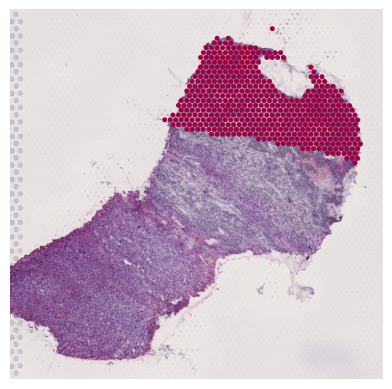

In [81]:
sc.pl.spatial(adata_result, 
              color='layer',  
              groups=['0'],  # 指定要显示的层
              spot_size=100,    
              palette=colors,
              alpha_img=1,
              legend_loc=None,
              title='',
              frameon=False,)

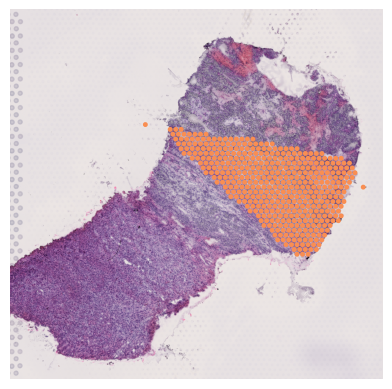

In [80]:
sc.pl.spatial(adata_result, 
              color='layer',  
              groups=['1'],  # 指定要显示的层
              spot_size=100,    
              palette=colors,
              alpha_img=1,
              legend_loc=None,
              title='',
              frameon=False,)

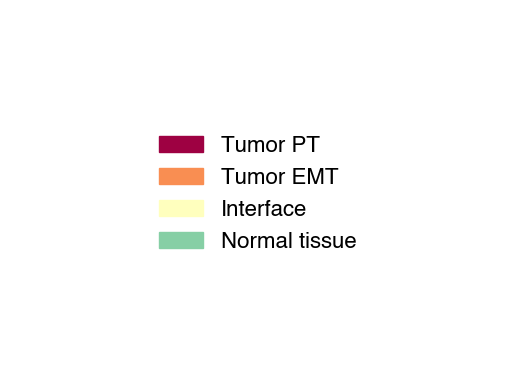

In [57]:
# plot legend for 4 layers
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
layer_names = ['Tumor PT', 'Tumor EMT', 'Interface', 'Normal tissue']
layer_colors = colors
patches = [mpatches.Patch(color=layer_colors[i], label=layer_names[i]) for i in range(len(layer_names))]
plt.legend(handles=patches, loc='center', frameon=False, fontsize=16)
plt.axis('off')
plt.show()

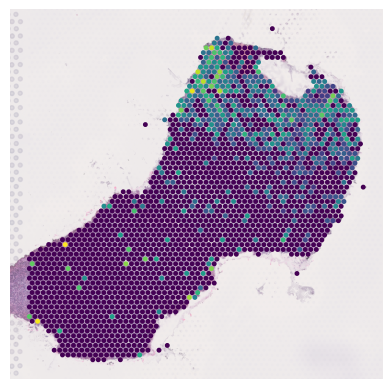

In [77]:
sc.pl.spatial(adata_result, color='ACSM2B',  
              spot_size=100,    
              #palette=colors,
              alpha_img=0.7,
              colorbar_loc=None,
              title='',
              frameon=False,)

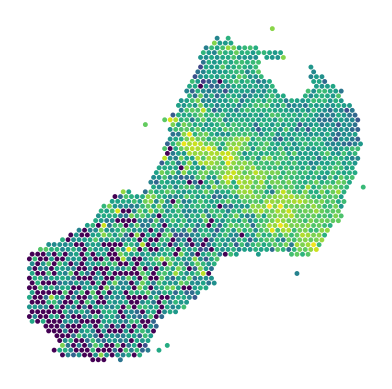

In [82]:
sc.pl.spatial(adata_result, color='MT2A',  
              spot_size=100,    
              #palette=colors,
              alpha_img=0.7,
              colorbar_loc=None,
              title='',
              img_key=None,
              frameon=False,)

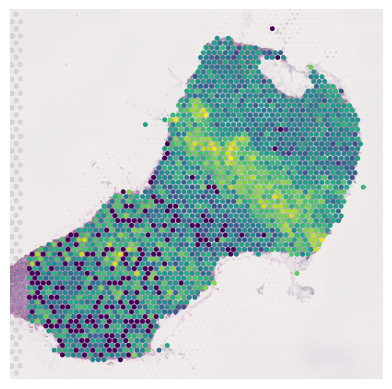

In [ ]:
sc.pl.spatial(adata_result, color='ANXA2',  
              spot_size=100,    
              #palette=colors,
              alpha_img=0.7,
              colorbar_loc=None,
              title='',
              ima
              frameon=False,)

In [20]:
plot_genes = ['MT2A', 'ANXA2', 'ACSM2A', 'ACSM2B']

In [ ]:
sc.pl.spatial(adata_result, #color='layer',  
              spot_size=100,    
              #palette=colors,
              alpha_img=1,
              legend_loc=None,
              title='',
              frameon=False,)

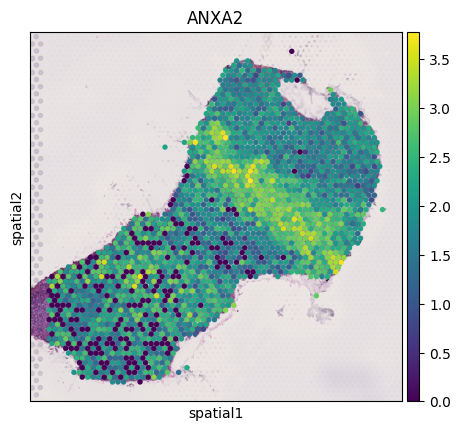

In [24]:
sc.pl.spatial(adata_result, color='ANXA2', size=1.5)

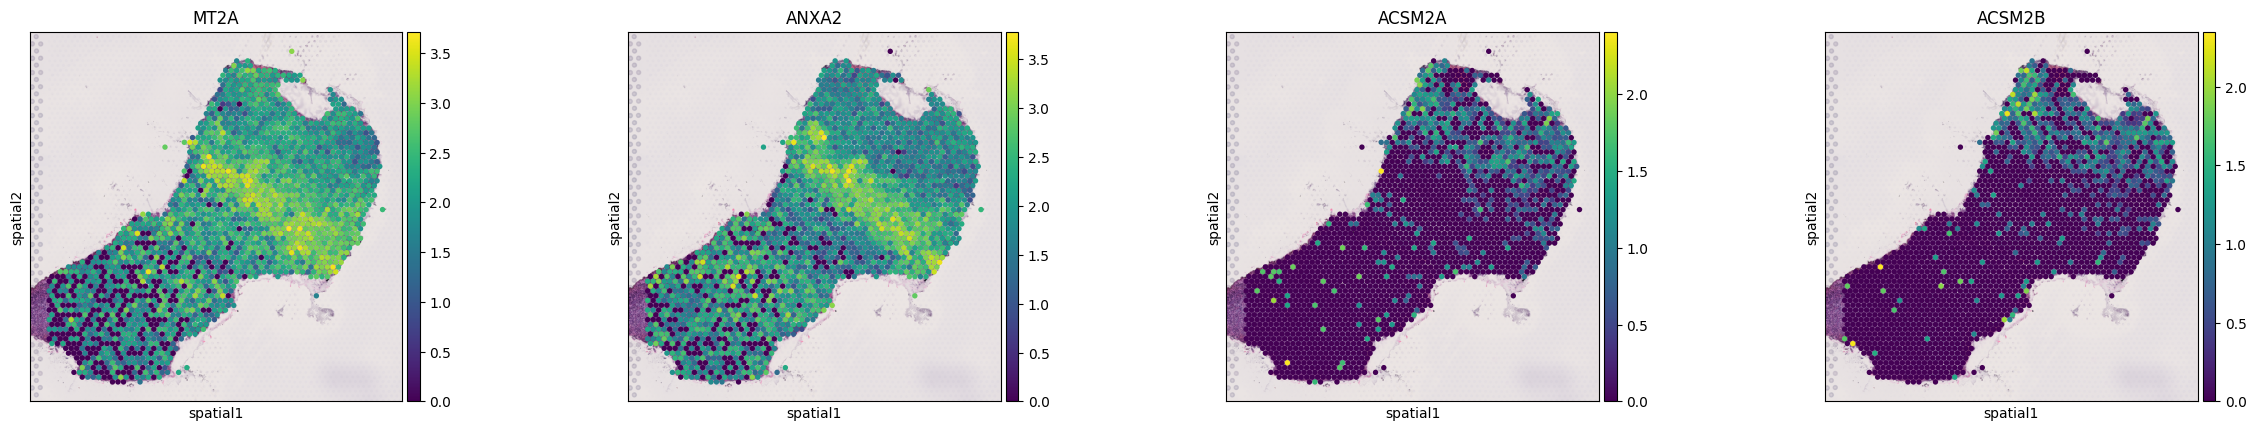

In [22]:
sc.pl.spatial(adata_result, color=plot_genes, size=1.5)

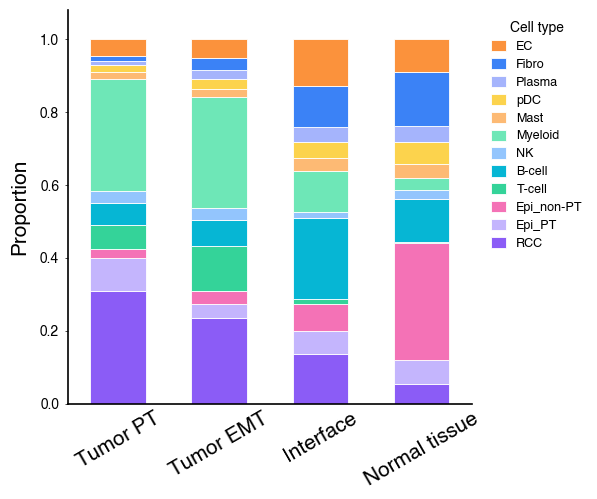

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

# ============================================================
# 1. 提取 proportion 和 layer 信息
# ============================================================
prop = adata_result.obsm['proportion']
if isinstance(prop, np.ndarray):
    cell_types = adata_result.uns.get('cell_type_names', 
                    [f'CellType_{i}' for i in range(prop.shape[1])])
    prop_df = pd.DataFrame(prop, columns=cell_types, index=adata_result.obs_names)
else:
    prop_df = pd.DataFrame(prop, index=adata_result.obs_names)

prop_df['layer'] = adata_result.obs['layer'].values

# ============================================================
# 2. 自定义细胞类型顺序（从下到上的堆叠顺序）
# ============================================================
cell_type_order = [
    # 肿瘤/上皮
    'RCC', 'Epi_PT', 'Epi_non-PT',
    # 免疫
    'T-cell', 'B-cell', 'NK', 'Myeloid', 'Mast', 'pDC', 'Plasma',
    # 基质
    'Fibro', 'EC',
]
# ↑↑↑ 直接调整这个列表的顺序即可，最前面的在柱子最底部 ↑↑↑

# 自动补全：防止遗漏
all_ct = [c for c in prop_df.columns if c != 'layer']
cell_type_order = [ct for ct in cell_type_order if ct in all_ct]
cell_type_order += [ct for ct in all_ct if ct not in cell_type_order]

# ============================================================
# 3. 计算每个 layer 的平均细胞组成（按自定义顺序）
# ============================================================
mean_prop = prop_df.groupby('layer')[cell_type_order].mean()

# ============================================================
# 自定义 layer 顺序和标签
# ============================================================
layer_order = ['0', '1', '2', '3']
layer_labels = {
    '0': 'Tumor PT',
    '1': 'Tumor EMT',
    '2': 'Interface',
    '3': 'Normal tissue',
}
mean_prop = mean_prop.loc[layer_order]

# ============================================================
# 自定义配色
# ============================================================
color_map = {
    'RCC':        '#8B5CF6',
    'Epi_PT':     '#C4B5FD',
    'Epi_non-PT': '#F472B6',
    'T-cell':     '#34D399',
    'B-cell':     '#06B6D4',
    'Myeloid':    '#6EE7B7',
    'NK':         '#93C5FD',
    'Plasma':     '#A5B4FC',
    'pDC':        '#FCD34D',
    'Mast':       '#FDBA74',
    'Fibro':      '#3B82F6',
    'EC':         '#FB923C',
}
colors = [color_map.get(ct, '#D1D5DB') for ct in cell_type_order]

# ============================================================
# 4. 绘图
# ============================================================
fig, ax = plt.subplots(figsize=(6, 5))

x = np.arange(len(mean_prop))
bar_width = 0.55

bottom = np.zeros(len(mean_prop))
for i, ct in enumerate(cell_type_order):
    ax.bar(x, mean_prop[ct], bottom=bottom, width=bar_width,
           label=ct, color=colors[i], edgecolor='white', linewidth=0.6)
    bottom += mean_prop[ct].values

# x 轴标签
ax.set_xticks(x)
ax.set_xticklabels([layer_labels[l] for l in layer_order], fontsize=15, rotation=30)

# 美化
ax.set_ylabel('Proportion', fontsize=15, labelpad=8)
ax.set_ylim(0, 1.08)
ax.set_xlim(-0.5, len(mean_prop) - 0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', length=0)

# 图例顺序反转，让图例从上到下与柱子从上到下一致
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1],
          bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9,
          frameon=False, title='Cell type', title_fontsize=10,
          handlelength=1.2, handleheight=1.0, labelspacing=0.4)

plt.tight_layout()
plt.show()